# Exemplo: Classificação de Sensores IoT usando k-NN

Suponha que desejamos classificar sensores como:

+ Classe 0: Funcionamento Normal
+ Classe 1: Funcionamento Anômalo

Utilizaremos dois atributos:

+ Temperatura (°C)
+ Consumo de Corrente (mA)

## Importando as bibliotecas

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

## Criando a base de treinamento

In [6]:
# Temperatura (°C) e Corrente (mA)
X = np.array([
    [25, 10],
    [27, 12],
    [26, 11],
    [29, 13],
    [40, 25],
    [42, 28],
    [43, 26],
    [45, 30]
])

# Classes
# 0 = Normal
# 1 = Anômalo
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

print("Base de treinamento:")
print(X)

Base de treinamento:
[[25 10]
 [27 12]
 [26 11]
 [29 13]
 [40 25]
 [42 28]
 [43 26]
 [45 30]]


## Treinando o modelo k-NN

Vamos utilizar: **k=3**

In [7]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X, y)

KNeighborsClassifier(n_neighbors=3)

# Classificando um novo sensor

Suponha um sensor com:

+ Temperatura = 30°C
+ Corrente = 14 mA

In [8]:
novo_sensor = np.array([[30, 14]])

classe_predita = knn.predict(novo_sensor)

if classe_predita == 0:
    print("Sensor NORMAL")
else:
    print("Sensor ANÔMALO")

Sensor NORMAL


## Mostrando os vizinhos mais próximos

In [9]:
distancias, indices = knn.kneighbors(novo_sensor)

print("Distâncias:")
print(distancias)

print("Índices dos vizinhos:")
print(indices)

Distâncias:
[[1.41421356 3.60555128 5.        ]]
Índices dos vizinhos:
[[3 1 2]]


Isso significa que o algoritmo encontrou os três sensores mais próximos e realizou uma votação entre eles.

## Visualizando graficamente

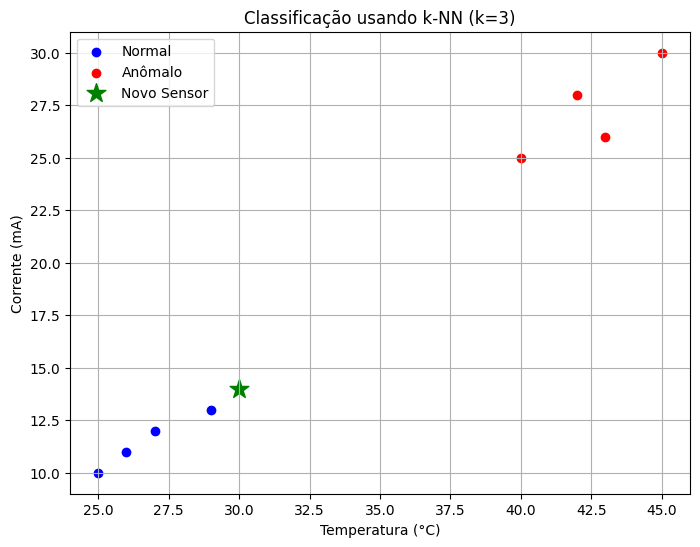

In [10]:
plt.figure(figsize=(8,6))

# Classe normal
plt.scatter(
    X[y==0,0],
    X[y==0,1],
    color='blue',
    label='Normal'
)

# Classe anômala
plt.scatter(
    X[y==1,0],
    X[y==1,1],
    color='red',
    label='Anômalo'
)

# Novo sensor
plt.scatter(
    novo_sensor[:,0],
    novo_sensor[:,1],
    color='green',
    s=200,
    marker='*',
    label='Novo Sensor'
)

plt.xlabel('Temperatura (°C)')
plt.ylabel('Corrente (mA)')
plt.title('Classificação usando k-NN (k=3)')
plt.legend()
plt.grid(True)

plt.show()

O k-NN  não aprende parâmetros.

Ele apenas armazena os exemplos.

Durante a predição, q uando chega um novo sensor, o algoritmo faz:

+ Calcula a distância para todos os pontos.
+ Seleciona os k vizinhos mais próximos.
+ Faz uma votação.
+ Atribui a classe vencedora.

## Exemplo do efeito de k

In [ ]:
for k in [1, 3, 5]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)

    pred = knn.predict(novo_sensor)

    print(f"k={k} -> classe={pred[0]}")

+ k = 1: mais sensível a ruído.
+ k = 3: geralmente mais robusto.
+ k = 5: decisão mais suave.
+ k muito grande: pode perder a capacidade de separar as classes.

## Qual é a complexidade computacional do k-NN?

Durante a predição, o k-NN precisa calcular a distância para todos os exemplos:

$$O(N⋅d),$$
onde:
+ N = número de amostras de treinamento
+ d = número de características

Portanto:

+ Treinamento → muito rápido.
+ Predição → pode ser lenta para bases grandes.

Isso permite introduzir estruturas como:

+ KD-Tree
+ Ball Tree

Que são estruturas de dados utilizadas para acelerar a busca dos vizinhos mais próximos em algoritmos como o k-NN.